# ___Mining and Heavy Equipment___

___Predicting Fuel Consumption for Heavy Duty Applications___

In [1]:
# Importing nessarcy Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score, # Coefficeient of determination (model fit)
    mean_squared_error, # penalizes large errors
    mean_absolute_error, # avearage absolue error
    explained_variance_score # How much variance the model explains
)

## ___1 - Loading the Data___
We will try to understand the data, clean, normalize and impute the data where ever possible to derive the best possible result out of the exsisting dataset.

Derived from - https://figshare.com/s/7e6f90fc08adc113f7a7?utm_source=copilot.com&file=54669416

In [3]:
# Reading Excel
df_main = pd.read_excel(r"D:\ML & AI\_Projects\Mining & Heavy Equipment\final_ori_data.xlsx", index_col = 0).iloc[1:].reset_index(drop=True)
df_main.head()

,date,Ton-kilometer fuel consumption L / km / t,vehicle model,Mileage km,Actual fueling quantity L,Average temperature ( ° F ),Average wind speed ( knots ),Maximum temperature ( ° F ),Minimum temperature ( ° F ),Precipitation ( in ),road quality,shift work,Raise height difference,Width of working flat
0,2023-04-20 00:00:00,0.021914,RTH136,NaN,NaN,41.8,3.6,54.7,25.5,0,1,night shift,95,30
1,2023-04-21 00:00:00,0.028246,RTH136,NaN,NaN,48.3,3.3,59.9,28.8,0,1,day shift,95,30
2,2023-04-21 00:00:00,0.022779,RTH136,NaN,NaN,48.3,3.3,59.9,28.8,0,1,night shift,95,30
3,2023-04-22 00:00:00,0.027787,RTH136,NaN,NaN,52.1,5.8,62.4,33.6,0,1,day shift,95,30
4,2023-04-22 00:00:00,0.024141,RTH136,NaN,NaN,52.1,5.8,62.4,33.6,0,1,night shift,95,30


## ___2 - Basic EDA (Understanding the data)___

In [4]:
df_main.size

4088

In [5]:
df_main.shape

(292, 14)

In [6]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 14 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   date                                       292 non-null    object
 1   Ton-kilometer fuel consumption L / km / t  292 non-null    object
 2   vehicle model                              292 non-null    object
 3   Mileage km                                 132 non-null    object
 4   Actual fueling quantity L                  150 non-null    object
 5   Average temperature ( ° F )                292 non-null    object
 6   Average wind speed ( knots )               292 non-null    object
 7   Maximum temperature ( ° F )                292 non-null    object
 8   Minimum temperature ( ° F )                292 non-null    object
 9   Precipitation ( in )                       292 non-null    object
 10  road quality                          

In [8]:
df_main.describe()

C:\Users\ANISH RANE\AppData\Local\Temp\ipykernel_19684\3685745363.py:1: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  df_main.describe()


,date,Ton-kilometer fuel consumption L / km / t,vehicle model,Mileage km,Actual fueling quantity L,Average temperature ( ° F ),Average wind speed ( knots ),Maximum temperature ( ° F ),Minimum temperature ( ° F ),Precipitation ( in ),road quality,shift work,Raise height difference,Width of working flat
count,292,292.0000,292,132,150,292.0,292.0,292.0,292.0,292,292,292,292,292
unique,41,257.0000,3,131,122,37.0,18.0,28.0,36.0,5,2,2,2,1
top,2023-05-23 00:00:00,0.0313,MT96L,17970,270,67.8,5.8,78.3,52.2,0,1,night shift,110,30
freq,26,28.0000,138,2,3,32.0,44.0,44.0,62.0,236,267,175,269,292


In [9]:
print(df_main.dtypes)

date                                         object
Ton-kilometer fuel consumption L / km / t    object
vehicle model                                object
Mileage km                                   object
Actual fueling quantity L                    object
Average temperature ( ° F )                  object
Average wind speed ( knots )                 object
Maximum temperature ( ° F )                  object
Minimum temperature ( ° F )                  object
Precipitation ( in )                         object
road quality                                 object
shift work                                   object
Raise height difference                      object
Width of working flat                        object
dtype: object


In [14]:
# auto convert types
df_main = df_main.infer_objects(copy=False)
df_main = df_main.convert_dtypes()

# verify
print(df_main.dtypes)

date                                         datetime64[ns]
Ton-kilometer fuel consumption L / km / t           Float64
vehicle model                                string[python]
Mileage km                                          Float64
Actual fueling quantity L                            object
Average temperature ( ° F )                         Float64
Average wind speed ( knots )                        Float64
Maximum temperature ( ° F )                         Float64
Minimum temperature ( ° F )                         Float64
Precipitation ( in )                                Float64
road quality                                          Int64
shift work                                   string[python]
Raise height difference                               Int64
Width of working flat                                 Int64
dtype: object


In [15]:
df_main['Actual fueling quantity L'] = pd.to_numeric(
    df_main['Actual fueling quantity L']
    .astype(str)
    .str.replace(r'[^0-9.]', '', regex = True),
    errors = 'coerce'
)
# verify
print(df_main.dtypes)

date                                         datetime64[ns]
Ton-kilometer fuel consumption L / km / t           Float64
vehicle model                                string[python]
Mileage km                                          Float64
Actual fueling quantity L                           float64
Average temperature ( ° F )                         Float64
Average wind speed ( knots )                        Float64
Maximum temperature ( ° F )                         Float64
Minimum temperature ( ° F )                         Float64
Precipitation ( in )                                Float64
road quality                                          Int64
shift work                                   string[python]
Raise height difference                               Int64
Width of working flat                                 Int64
dtype: object


In [16]:
null_df = pd.DataFrame({
    'Null Count': df_main.isnull().sum(),
    'Null %': np.round(((df_main.isnull().sum()/len(df_main))*100),2)
})

null_df = null_df[null_df['Null Count']>0].sort_values(by = "Null %", ascending = False)
null_df

,Null Count,Null %
Mileage km,160,54.79
Actual fueling quantity L,142,48.63


## ___3 - Handling missing values___
### ___Using KNN Imputer for Numerical Columns___

In [19]:
df = df_main.copy()
df.dtypes

date                                         datetime64[ns]
Ton-kilometer fuel consumption L / km / t           Float64
vehicle model                                string[python]
Mileage km                                          Float64
Actual fueling quantity L                           float64
Average temperature ( ° F )                         Float64
Average wind speed ( knots )                        Float64
Maximum temperature ( ° F )                         Float64
Minimum temperature ( ° F )                         Float64
Precipitation ( in )                                Float64
road quality                                          Int64
shift work                                   string[python]
Raise height difference                               Int64
Width of working flat                                 Int64
dtype: object

In [20]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

df_knn = df.copy() # Creating Copy of dataframe

num_cols = df_knn.select_dtypes(include='number').columns

# Initializing Obects 
scaler = StandardScaler()
imputer = KNNImputer(n_neighbors = 5)

df_knn[num_cols] = imputer.fit_transform(
    scaler.fit_transform(df_knn[num_cols])
)


In [21]:
df_knn_null = pd.DataFrame({
    'Null Count': df_knn.isnull().sum(),
    'Null %': np.round(((df_knn.isnull().sum()/len(df_knn))*100),2)
})

df_knn_null

,Null Count,Null %
date,0,0.0
Ton-kilometer fuel consumption L / km / t,0,0.0
vehicle model,0,0.0
Mileage km,0,0.0
Actual fueling quantity L,0,0.0
Average temperature ( ° F ),0,0.0
Average wind speed ( knots ),0,0.0
Maximum temperature ( ° F ),0,0.0
Minimum temperature ( ° F ),0,0.0
Precipitation ( in ),0,0.0


## ___4 - Deep EDA (Before Scaling)___

In [22]:
# Distribute the Set of Columns
date_cols = df_main.select_dtypes(include='datetime64[ns]')
cat_cols = df_main.select_dtypes(include='string')
num_cols = df_main.select_dtypes(include='number')

#### ___Understanding Numerical Columns___

In [23]:
stats = df_main[num_cols.columns].describe().T
stats['skew'] = df_main[num_cols.columns].skew()
stats['kurtosis'] = df_main[num_cols.columns].kurt()

stats

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Ton-kilometer fuel consumption L / km / t,292.0,0.047772,0.020061,0.020182,0.026466,0.05151,0.065584,0.128571,0.140741,-0.740259
Mileage km,132.0,13905.182576,4907.117503,4114.0,10253.5,11587.0,17859.75,24160.0,0.138257,-1.00842
Actual fueling quantity L,150.0,337.246667,117.553354,37.0,252.25,343.0,429.75,602.0,-0.154956,-0.723705
Average temperature ( ° F ),292.0,62.834247,6.266427,41.8,62.6,64.6,67.4,75.1,-1.471275,1.835325
Average wind speed ( knots ),292.0,5.538014,1.18607,2.6,4.2,5.8,6.1,7.2,-0.329928,-0.912601
Maximum temperature ( ° F ),292.0,75.421918,6.32669,51.1,74.8,78.0,78.4,87.1,-1.958128,4.209758
Minimum temperature ( ° F ),292.0,48.873288,6.059321,25.5,47.7,50.55,52.2,59.7,-1.479374,2.090503
Precipitation ( in ),292.0,0.013288,0.036366,0.0,0.0,0.0,0.0,0.15,3.074231,8.462378
road quality,292.0,1.171233,0.560554,1.0,1.0,1.0,1.0,3.0,2.977348,6.911899
Raise height difference,292.0,108.818493,4.047561,95.0,110.0,110.0,110.0,110.0,-3.143656,7.936887


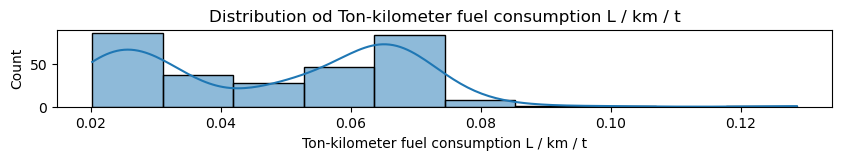

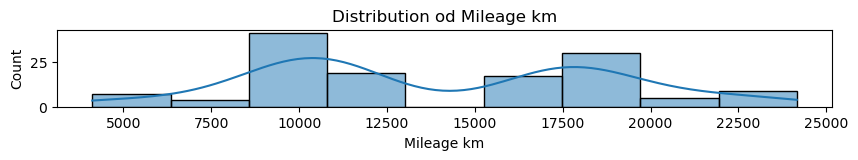

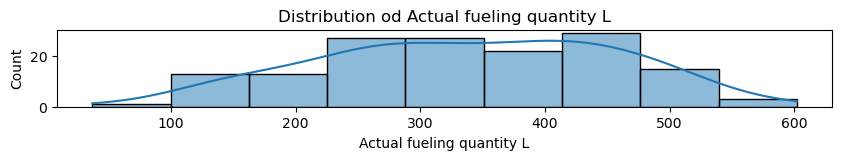

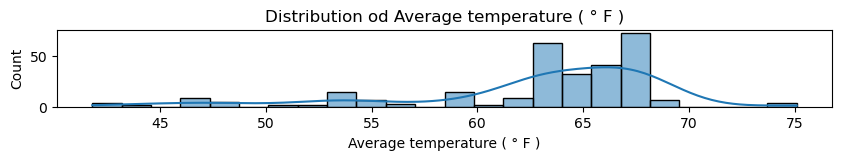

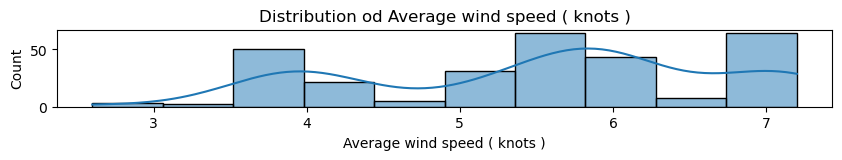

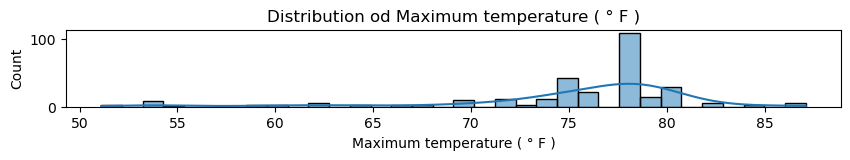

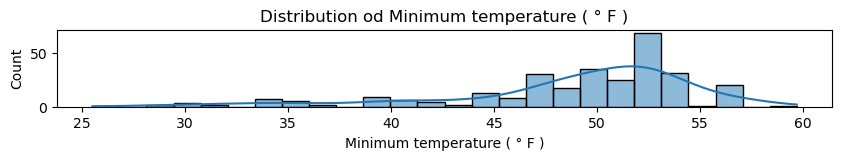

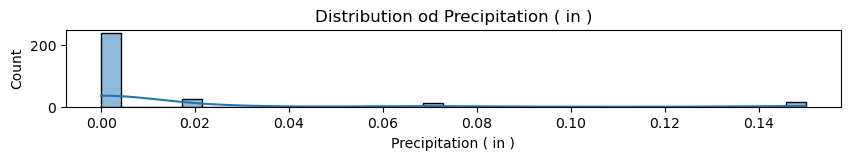

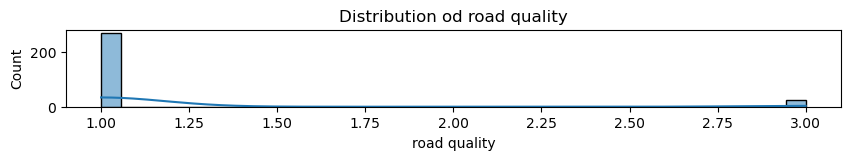

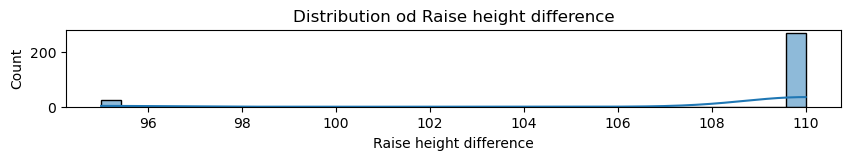

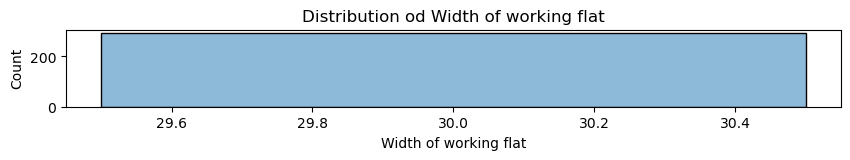

In [24]:
for col in num_cols.columns:
    plt.figure(figsize=(10,1))
    sns.histplot(df_main[col], kde=True)
    plt.title(f"Distribution od {col}")
    plt.show()

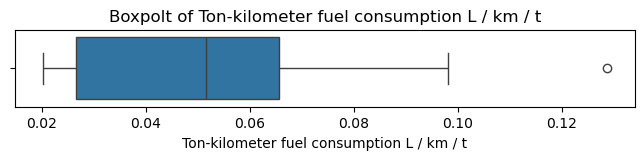

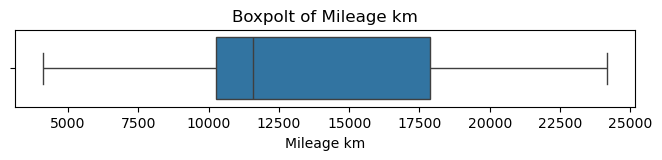

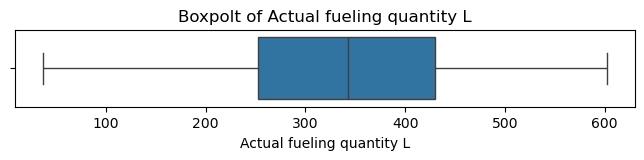

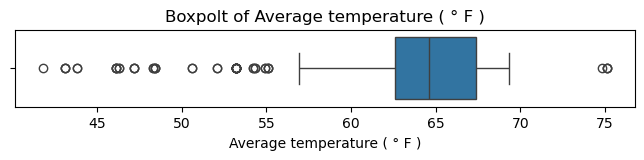

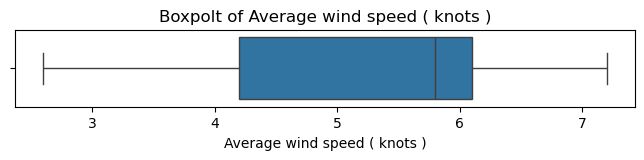

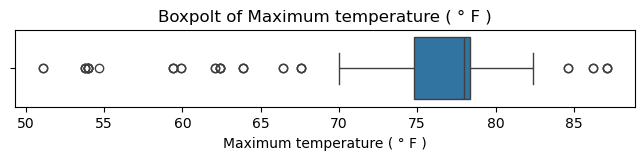

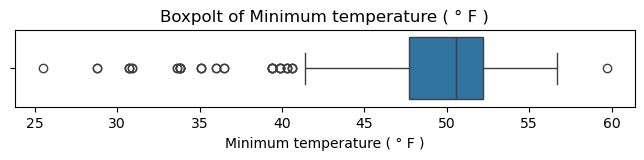

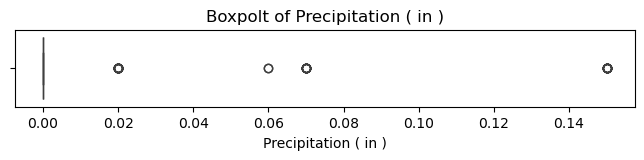

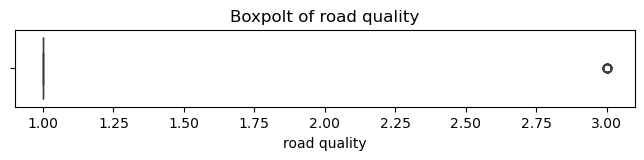

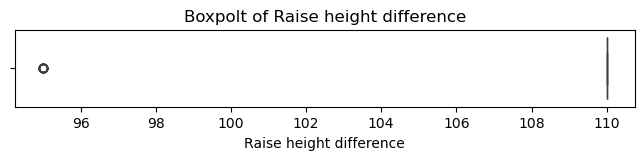

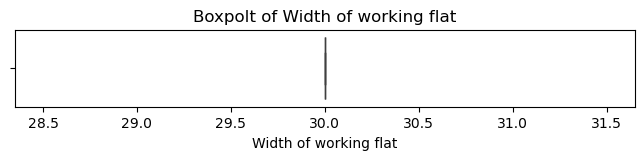

In [26]:
for col in num_cols.columns:
    plt.figure(figsize=(8,1))
    sns.boxplot(x = df_main[col])
    plt.title(f"Boxpolt of {col}")
    plt.show()

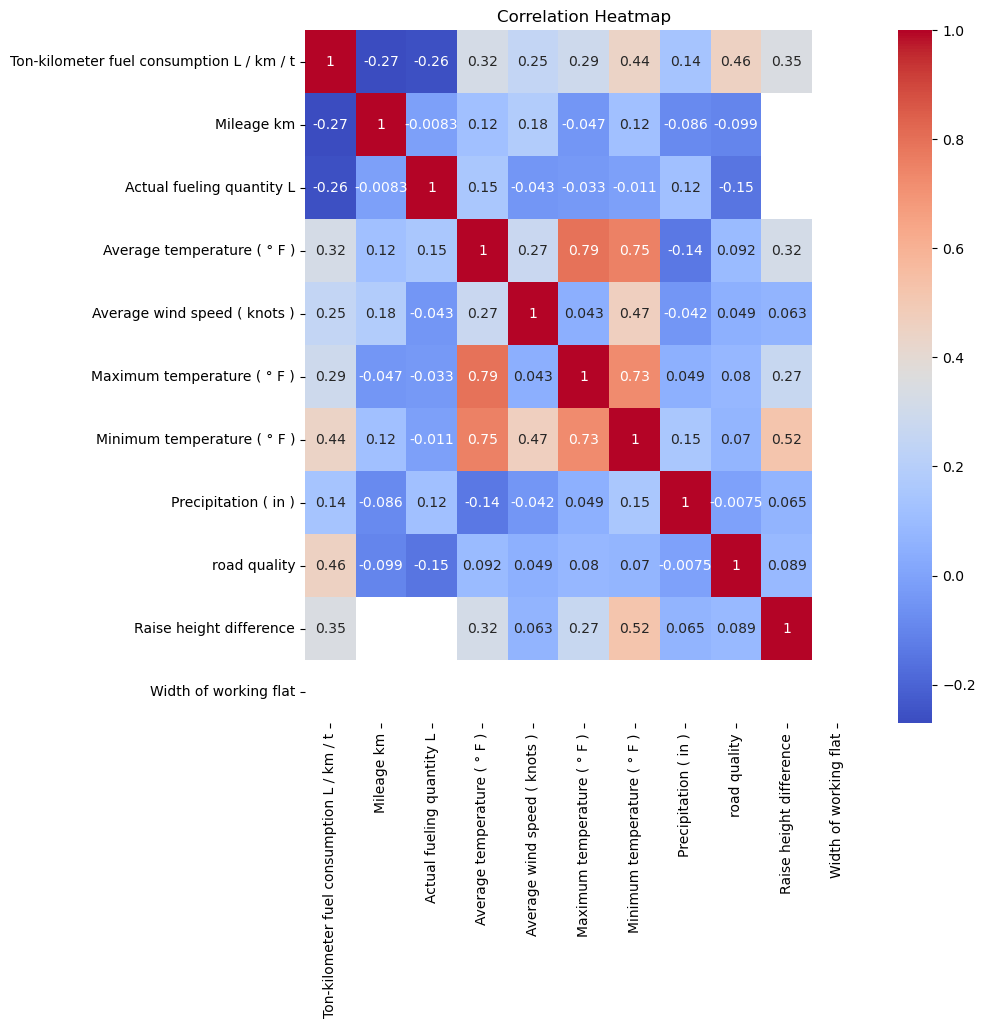

In [27]:
corr = df_main[num_cols.columns].corr()

plt.figure(figsize = (9,9))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### ___Understanding Categorical Columns___

In [28]:
for col in cat_cols.columns:
    print(df_main[col].value_counts())

vehicle model
MT96L      138
RTH136     133
SKT105E     21
Name: count, dtype: Int64
shift work
night shift    175
day shift      117
Name: count, dtype: Int64


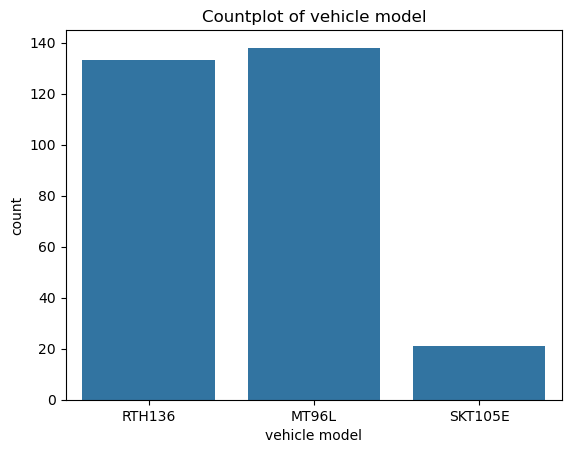

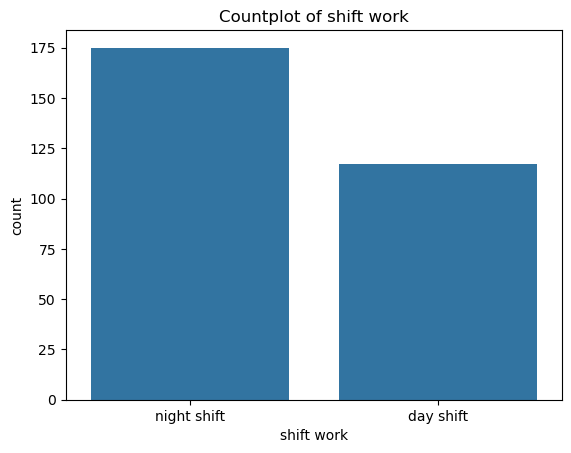

In [29]:
for col in cat_cols.columns:
    plt.figure()
    sns.countplot(x=df_main[col])
    plt.title(f"Countplot of {col}")
    plt.show()

 ___Target vs Category___

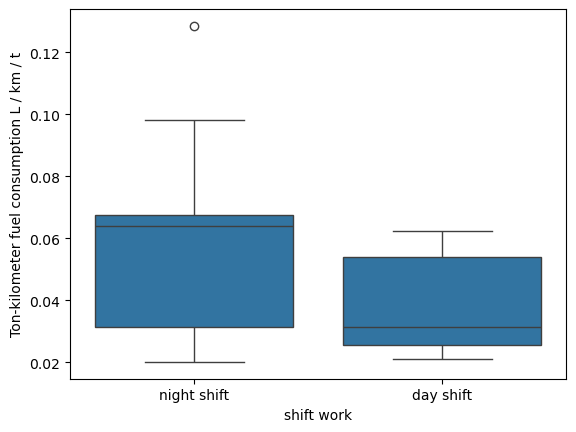

In [30]:
sns.boxplot(x='shift work',y='Ton-kilometer fuel consumption L / km / t', data=df_main)
plt.show()

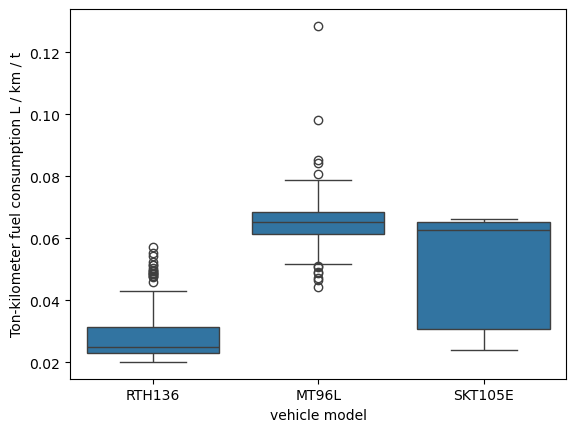

In [31]:
sns.boxplot(x='vehicle model',y='Ton-kilometer fuel consumption L / km / t', data=df_main)
plt.show()

In [33]:
for col in date_cols.columns:

    df_main[col+'_year'] = df_main[col].dt.year
    df_main[col+'_month'] = df_main[col].dt.month
    df_main[col+'_day'] = df_main[col].dt.day
    df_main[col+'_dayofweek'] = df_main[col].dt.dayofweek


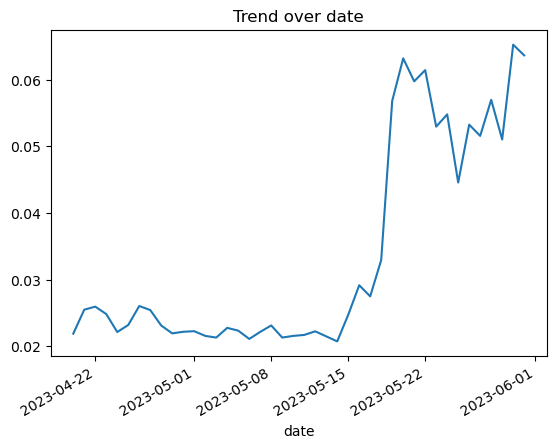

In [34]:
for col in date_cols.columns:
    
    df_main.groupby(col)[num_cols.columns[0]].mean().plot()
    
    plt.title(f"Trend over {col}")
    plt.show()


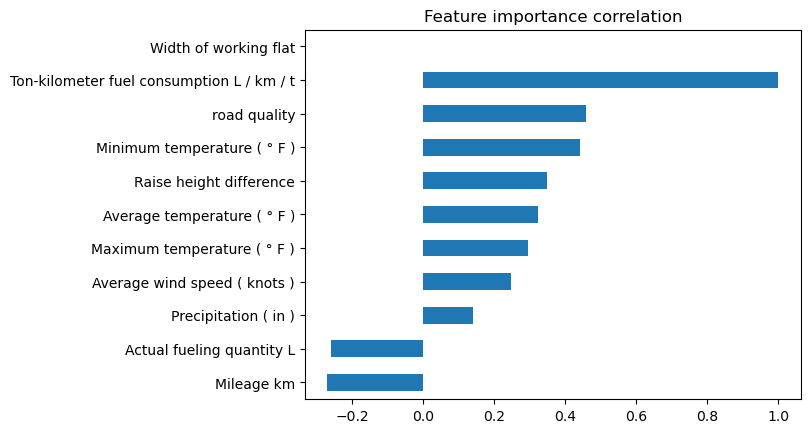

In [35]:
target = 'Ton-kilometer fuel consumption L / km / t'

corr_target = df_main[num_cols.columns].corr()[target].sort_values()

corr_target.plot(kind='barh')
plt.title("Feature importance correlation")
plt.show()


# ___Adding more data to make it scalable___
Instead of using only vehicle model name, use vehicle specifications as features.

In [38]:
vehical_specs = {
    "MT96L" : {
        "Engine power (HP)": 523,
        "Engine size (L)": 12.54,
        "Vehicle weight (kg)": 33000,
        "Transmission type": "Automatic",
        "Fuel Type": "Diesel",
        "Numbers of cylinder": 6,
        "Load Capacity": 65000
    },
    "RTH136":{
        "Engine power (HP)": 764,
        "Engine size (L)": 15.93,
        "Vehicle weight (kg)": 48000,
        "Transmission type": "Automatic",
        "Fuel Type": "Diesel",
        "Numbers of cylinder": 6,
        "Load Capacity": 100000
    },
    "SKT105E":{
        "Engine power (HP)": 523,
        "Engine size (L)": 12.54,
        "Vehicle weight (kg)": 38000,
        "Transmission type": "Automatic",
        "Fuel Type": "Diesel",
        "Numbers of cylinder": 6,
        "Load Capacity": 70000
    }
}

In [41]:
spec_df = pd.DataFrame.from_dict(vehical_specs, orient ='index')
spec_df

,Engine power (HP),Engine size (L),Vehicle weight (kg),Transmission type,Fuel Type,Numbers of cylinder,Load Capacity
MT96L,523,12.54,33000,Automatic,Diesel,6,65000
RTH136,764,15.93,48000,Automatic,Diesel,6,100000
SKT105E,523,12.54,38000,Automatic,Diesel,6,70000


In [42]:
df_main = df_main.merge(spec_df, left_on='vehicle model', right_index=True, how='left')

In [43]:
df_main

,date,Ton-kilometer fuel consumption L / km / t,vehicle model,Mileage km,Actual fueling quantity L,Average temperature ( ° F ),Average wind speed ( knots ),Maximum temperature ( ° F ),Minimum temperature ( ° F ),Precipitation ( in ),...,date_month,date_day,date_dayofweek,Engine power (HP),Engine size (L),Vehicle weight (kg),Transmission type,Fuel Type,Numbers of cylinder,Load Capacity
0,2023-04-20,0.021914,RTH136,<NA>,NaN,41.8,3.6,54.7,25.5,0.0,...,4,20,3,764,15.93,48000,Automatic,Diesel,6,100000
1,2023-04-21,0.028246,RTH136,<NA>,NaN,48.3,3.3,59.9,28.8,0.0,...,4,21,4,764,15.93,48000,Automatic,Diesel,6,100000
2,2023-04-21,0.022779,RTH136,<NA>,NaN,48.3,3.3,59.9,28.8,0.0,...,4,21,4,764,15.93,48000,Automatic,Diesel,6,100000
3,2023-04-22,0.027787,RTH136,<NA>,NaN,52.1,5.8,62.4,33.6,0.0,...,4,22,5,764,15.93,48000,Automatic,Diesel,6,100000
4,2023-04-22,0.024141,RTH136,<NA>,NaN,52.1,5.8,62.4,33.6,0.0,...,4,22,5,764,15.93,48000,Automatic,Diesel,6,100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,2023-05-21,0.067745,MT96L,<NA>,NaN,64.6,5.8,78.4,54.1,0.0,...,5,21,6,523,12.54,33000,Automatic,Diesel,6,65000
288,2023-05-22,0.066437,MT96L,<NA>,NaN,63.0,5.6,74.8,53.2,0.15,...,5,22,0,523,12.54,33000,Automatic,Diesel,6,65000
289,2023-05-22,0.066437,MT96L,<NA>,NaN,63.0,5.6,74.8,53.2,0.15,...,5,22,0,523,12.54,33000,Automatic,Diesel,6,65000
290,2023-05-23,0.04724,MT96L,<NA>,NaN,63.1,6.9,74.8,52.2,0.02,...,5,23,1,523,12.54,33000,Automatic,Diesel,6,65000


In [91]:
col = [
    'Average temperature ( ° F )',
    'Maximum temperature ( ° F )',
    'Minimum temperature ( ° F )',
    'Precipitation ( in )',
    'road quality',
    'Raise height difference'
]

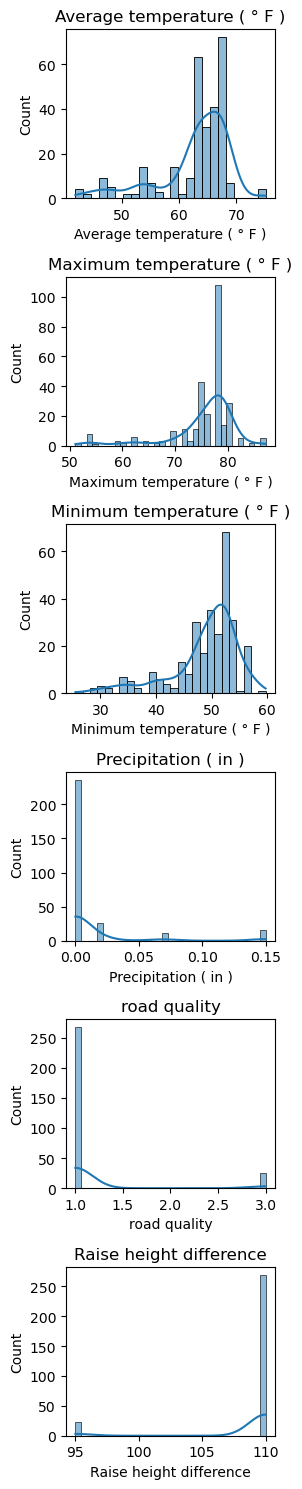

In [93]:
# Figuring out the skewness 
fig, axes = plt.subplots(len(col), 1, figsize = (3,15))

for i, cols in enumerate(col):
    sns.histplot(df_main[cols], kde=True, ax = axes[i])
    axes[i].set_title(cols)

plt.tight_layout()
plt.show()

Lets use QuantileTransformer for Average temperature ( ° F )', 'Maximum temperature ( ° F )', 'Minimum temperature ( ° F )'

In [98]:
# Handeling the Skew Data 
from sklearn.preprocessing import QuantileTransformer

pt = QuantileTransformer(
    n_quantiles=292,  # or 200
    output_distribution='normal',
    random_state=42
)

cols = [
    'Average temperature ( ° F )', 
    'Maximum temperature ( ° F )', 
    'Minimum temperature ( ° F )',
]

df_main[cols] = pt.fit_transform(df_main[cols])

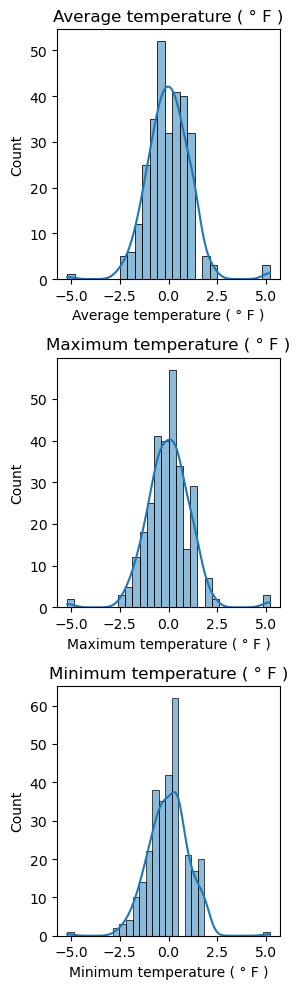

In [99]:
fig, axes = plt.subplots(len(cols), 1, figsize = (3,10))

for i, cols in enumerate(cols):
    sns.histplot(df_main[cols], kde=True, ax = axes[i])
    axes[i].set_title(cols)

plt.tight_layout()
plt.show()

In [101]:
cols_clip = [
    'Precipitation ( in )',
    'road quality',
    'Raise height difference'
]

for col in cols_clip:
    df_main[cols_clip] = np.log1p(df_main[cols_clip])

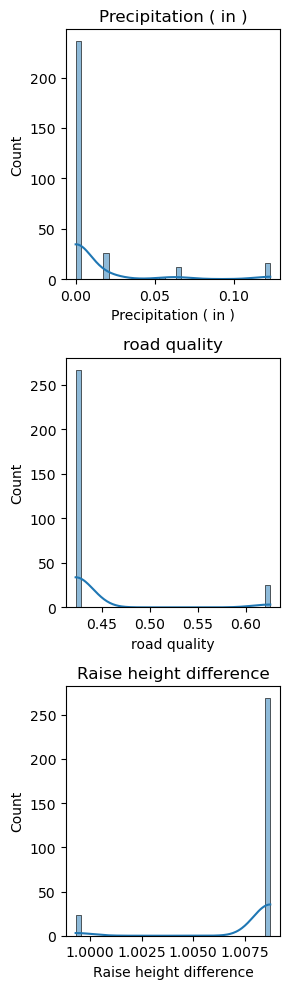

In [103]:
fig, axes = plt.subplots(len(cols_clip), 1, figsize = (3,10))

for i, cols in enumerate(cols_clip):
    sns.histplot(df_main[cols], kde=True, ax = axes[i])
    axes[i].set_title(cols)

plt.tight_layout()
plt.show()

We will use robust Scalar for 'Precipitation ( in )','road quality','Raise height difference'

## ___Feature Engineering___
We have date and time column and we can extract meangin full data from the column Line day, month, week, year

In [7]:
import datetime as dt

df_main['year'] = df_main['date'].dt.year
df_main['month'] = df_main['date'].dt.month
df_main['day'] = df_main['date'].dt.day
df_main['day_of_week'] = df_main['date'].dt.dayofweek
df_main['day_of_year'] = df_main['date'].dt.dayofyear

df_main.head()

,date,Ton-kilometer fuel consumption L / km / t,vehicle model,Mileage km,Actual fueling quantity L,Average temperature ( ° F ),Average wind speed ( knots ),Maximum temperature ( ° F ),Minimum temperature ( ° F ),Precipitation ( in ),road quality,shift work,Raise height difference,Width of working flat,year,month,day,day_of_week,day_of_year
0,2023-04-20,0.021914,RTH136,<NA>,NaN,41.8,3.6,54.7,25.5,0.0,1,night shift,95,30,2023,4,20,3,110
1,2023-04-21,0.028246,RTH136,<NA>,NaN,48.3,3.3,59.9,28.8,0.0,1,day shift,95,30,2023,4,21,4,111
2,2023-04-21,0.022779,RTH136,<NA>,NaN,48.3,3.3,59.9,28.8,0.0,1,night shift,95,30,2023,4,21,4,111
3,2023-04-22,0.027787,RTH136,<NA>,NaN,52.1,5.8,62.4,33.6,0.0,1,day shift,95,30,2023,4,22,5,112
4,2023-04-22,0.024141,RTH136,<NA>,NaN,52.1,5.8,62.4,33.6,0.0,1,night shift,95,30,2023,4,22,5,112


In [8]:
# Adding in cyclic data

# For Month
df_main['month_sin'] = np.sin(2*np.pi*df_main['month']/12)
df_main['month_cos'] = np.cos(2*np.pi*df_main['month']/12)

# For Day of the week
df_main['dow_sin'] = np.sin(2*np.pi*df_main['day_of_week']/7)
df_main['dow_cos'] = np.cos(2*np.pi*df_main['day_of_week']/7)

# Day of the year 
df_main['doy_sin'] = np.sin(2*np.pi*df_main['day_of_year']/365)
df_main['doy_cos'] = np.cos(2*np.pi*df_main['day_of_year']/365)

In [9]:
df_main.drop(columns='date', inplace = True)

In [10]:
df_main.head()

,Ton-kilometer fuel consumption L / km / t,vehicle model,Mileage km,Actual fueling quantity L,Average temperature ( ° F ),Average wind speed ( knots ),Maximum temperature ( ° F ),Minimum temperature ( ° F ),Precipitation ( in ),road quality,...,month,day,day_of_week,day_of_year,month_sin,month_cos,dow_sin,dow_cos,doy_sin,doy_cos
0,0.021914,RTH136,<NA>,NaN,41.8,3.6,54.7,25.5,0.0,1,...,4,20,3,110,0.866025,-0.5,0.433884,-0.900969,0.948362,-0.317191
1,0.028246,RTH136,<NA>,NaN,48.3,3.3,59.9,28.8,0.0,1,...,4,21,4,111,0.866025,-0.5,-0.433884,-0.900969,0.942761,-0.333469
2,0.022779,RTH136,<NA>,NaN,48.3,3.3,59.9,28.8,0.0,1,...,4,21,4,111,0.866025,-0.5,-0.433884,-0.900969,0.942761,-0.333469
3,0.027787,RTH136,<NA>,NaN,52.1,5.8,62.4,33.6,0.0,1,...,4,22,5,112,0.866025,-0.5,-0.974928,-0.222521,0.936881,-0.349647
4,0.024141,RTH136,<NA>,NaN,52.1,5.8,62.4,33.6,0.0,1,...,4,22,5,112,0.866025,-0.5,-0.974928,-0.222521,0.936881,-0.349647


### ___One Hot Encoding for Categorical Varialbles___

In [12]:
df_main.select_dtypes(include = 'string').columns

Index(['vehicle model', 'shift work'], dtype='object')

In [13]:
# Categorical Columns 
cat_cols = df_main.select_dtypes(include = 'string').columns

# Encoding
df_main = pd.get_dummies(df_main, columns = cat_cols, drop_first = True)

# Converting from bool to int
df_main[['vehicle model_RTH136', 'vehicle model_SKT105E', 'shift work_night shift']] = df_main[['vehicle model_RTH136', 'vehicle model_SKT105E', 'shift work_night shift']].astype(int)

In [14]:
df_main.head()

,Ton-kilometer fuel consumption L / km / t,Mileage km,Actual fueling quantity L,Average temperature ( ° F ),Average wind speed ( knots ),Maximum temperature ( ° F ),Minimum temperature ( ° F ),Precipitation ( in ),road quality,Raise height difference,...,day_of_year,month_sin,month_cos,dow_sin,dow_cos,doy_sin,doy_cos,vehicle model_RTH136,vehicle model_SKT105E,shift work_night shift
0,0.021914,<NA>,NaN,41.8,3.6,54.7,25.5,0.0,1,95,...,110,0.866025,-0.5,0.433884,-0.900969,0.948362,-0.317191,1,0,1
1,0.028246,<NA>,NaN,48.3,3.3,59.9,28.8,0.0,1,95,...,111,0.866025,-0.5,-0.433884,-0.900969,0.942761,-0.333469,1,0,0
2,0.022779,<NA>,NaN,48.3,3.3,59.9,28.8,0.0,1,95,...,111,0.866025,-0.5,-0.433884,-0.900969,0.942761,-0.333469,1,0,1
3,0.027787,<NA>,NaN,52.1,5.8,62.4,33.6,0.0,1,95,...,112,0.866025,-0.5,-0.974928,-0.222521,0.936881,-0.349647,1,0,0
4,0.024141,<NA>,NaN,52.1,5.8,62.4,33.6,0.0,1,95,...,112,0.866025,-0.5,-0.974928,-0.222521,0.936881,-0.349647,1,0,1
